In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:
# LOAD DATASET
# ==========================================

df = pd.read_csv("shop_smart_ecommerce (1).csv")
# ==========================================
# DATA EXPLORATION
# ==========================================

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


First 5 Rows
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0        

# EDA

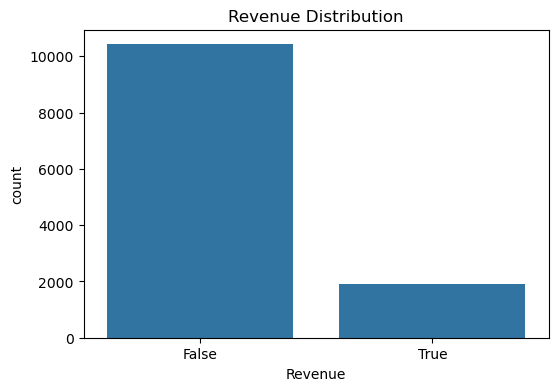

In [3]:

# Revenue Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Revenue", data=df)

plt.title("Revenue Distribution")

plt.show()


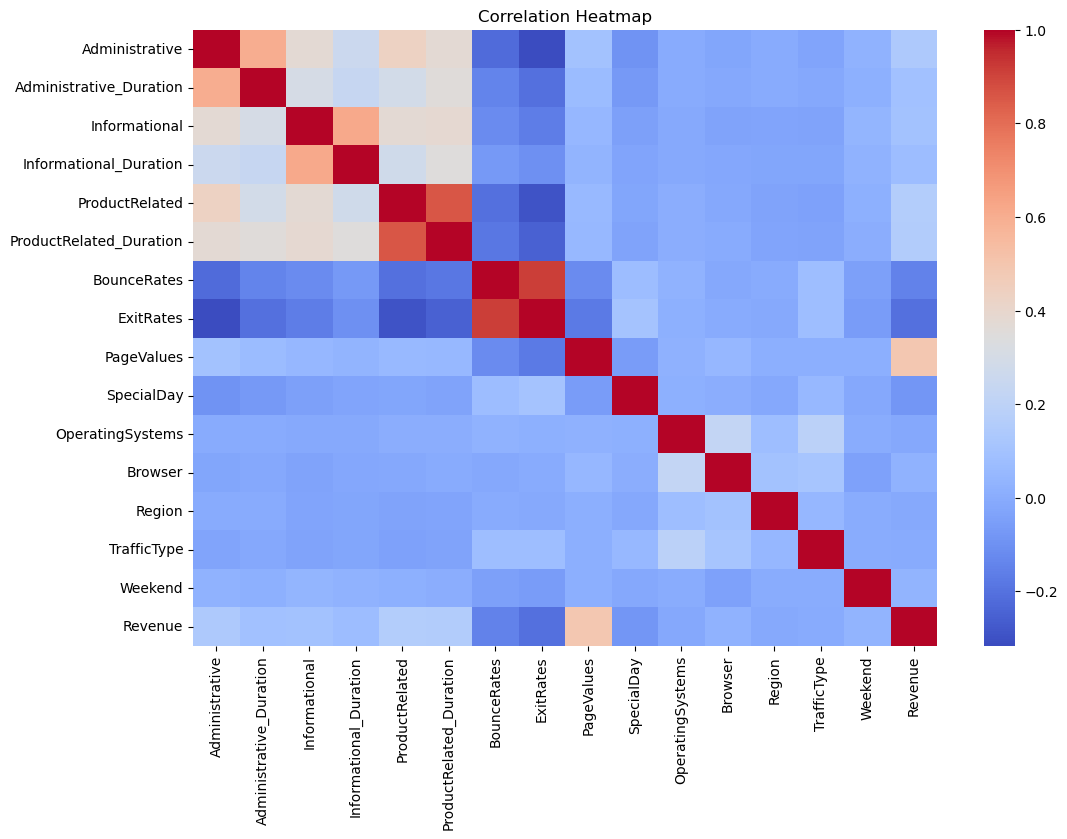

In [4]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


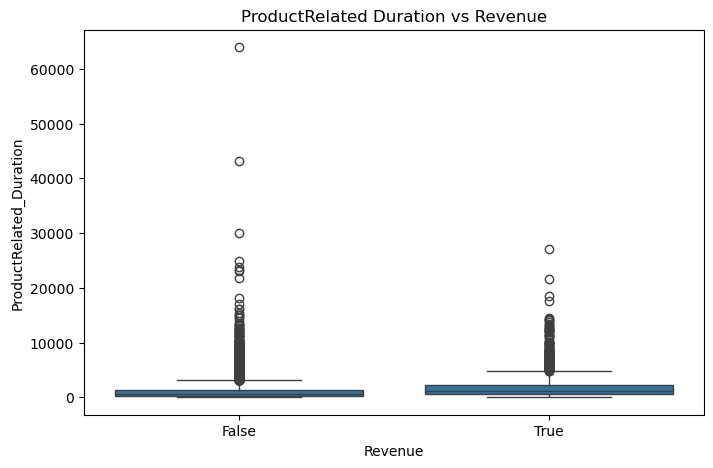

In [5]:
# Product Related Duration vs Revenue

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Revenue",
    y="ProductRelated_Duration",
    data=df
)

plt.title("ProductRelated Duration vs Revenue")

plt.show()


# DATA PREPROCESSING

In [6]:
le = LabelEncoder()

# Encode categorical columns

df["Month"] = le.fit_transform(df["Month"])

df["VisitorType"] = le.fit_transform(df["VisitorType"])

# Convert Boolean columns

df["Weekend"] = df["Weekend"].astype(int)

df["Revenue"] = df["Revenue"].astype(int)


In [7]:
# FEATURES AND TARGEt
X = df.drop("Revenue", axis=1)

y = df["Revenue"]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [10]:
y_pred = model.predict(X_test)


In [11]:
# MODEL EVALUATION
print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))

print("\nPrecision Score")
print(precision_score(y_test, y_pred))

print("\nRecall Score")
print(recall_score(y_test, y_pred))

print("\nF1 Score")
print(f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))



Accuracy Score
0.8550959718842931

Precision Score
0.5335820895522388

Recall Score
0.5

F1 Score
0.516245487364621

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      3127
           1       0.53      0.50      0.52       572

    accuracy                           0.86      3699
   macro avg       0.72      0.71      0.72      3699
weighted avg       0.85      0.86      0.85      3699



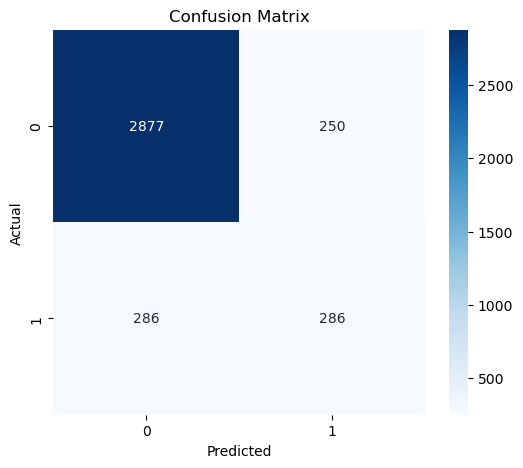

In [12]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [13]:
# DECISION TREE PRUNING

path = model.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

models = []

for alpha in ccp_alphas:

    pruned_model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        class_weight="balanced",
        random_state=42
    )

    pruned_model.fit(X_train, y_train)

    models.append((alpha, pruned_model))


In [14]:
# SELECT BEST MODEL USING F1 SCOR

best_f1 = 0

best_alpha = 0

best_model = None

for alpha, model in models:

    y_pred = model.predict(X_test)

    score = f1_score(y_test, y_pred)

    if score > best_f1:

        best_f1 = score

        best_alpha = alpha

        best_model = model

print("\nBest Alpha")
print(best_alpha)

print("\nBest F1 Score")
print(best_f1)



Best Alpha
0.0054822482025038005

Best F1 Score
0.64


In [16]:
# FINAL MODEL EVALUATION

final_pred = best_model.predict(X_test)

print("\nFinal F1 Score")
print(f1_score(y_test, final_pred))



Final F1 Score
0.64


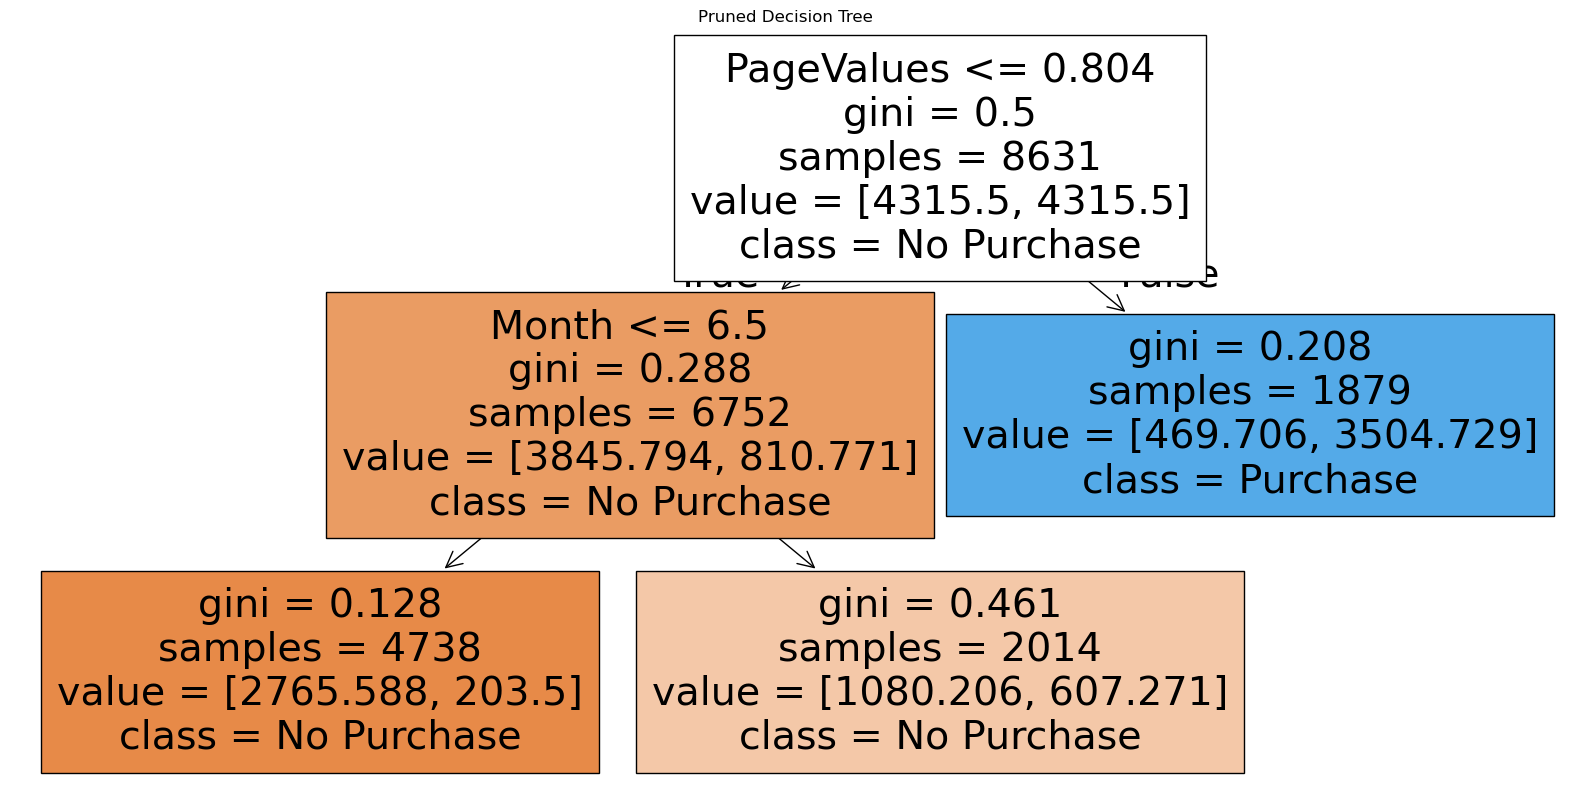

In [22]:
# VISUALIZE FINAL TREE
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["No Purchase", "Purchase"],
    filled=True
)

plt.title("Pruned Decision Tree")

plt.show()